# PR-9: Compositional Probe Transfer

Pandey-style probe transfer across all 20 directed concept pairs.
For each (C1→C2): train probe on atomic C1, evaluate on C1+C2 pairs.
**ΔR² = atomic − pair** measures how much C2 degrades C1's linear readout.


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

RESULTS_DIR = Path("results/synthetic")
MODELS = ["moiraie", "moiraic"]
MODEL_LABELS = {"moiraie": "Encoder (moiraie)", "moiraic": "Decoder (moiraic)"}

data = {}
for m in MODELS:
    p = RESULTS_DIR / f"{m}_compositional.json"
    with open(p) as f:
        data[m] = json.load(f)

# Collect all pair keys and layer indices from one model
sample = data[MODELS[0]]["mean_ctx"]
PAIR_KEYS = sorted(sample.keys())
LAYERS = sorted(int(k) for k in next(iter(sample.values())).keys())
print(f"Pairs: {len(PAIR_KEYS)}, Layers: {LAYERS}")
print("Example pairs:", PAIR_KEYS[:5])

Pairs: 20, Layers: [-1, 0, 1, 2, 3, 4, 5, 6, 7]
Example pairs: ['ar1→level_shift', 'ar1→seasonal', 'ar1→trend', 'ar1→var_shift', 'level_shift→ar1']


## 1. Interference heatmap (ΔR² at best layer per pair)

5×5 grid (C1 rows, C2 cols). Cell = max-layer ΔR² for that transfer.  
Positive (red) = C2 degrades C1 representation. Negative (blue) = synergy.

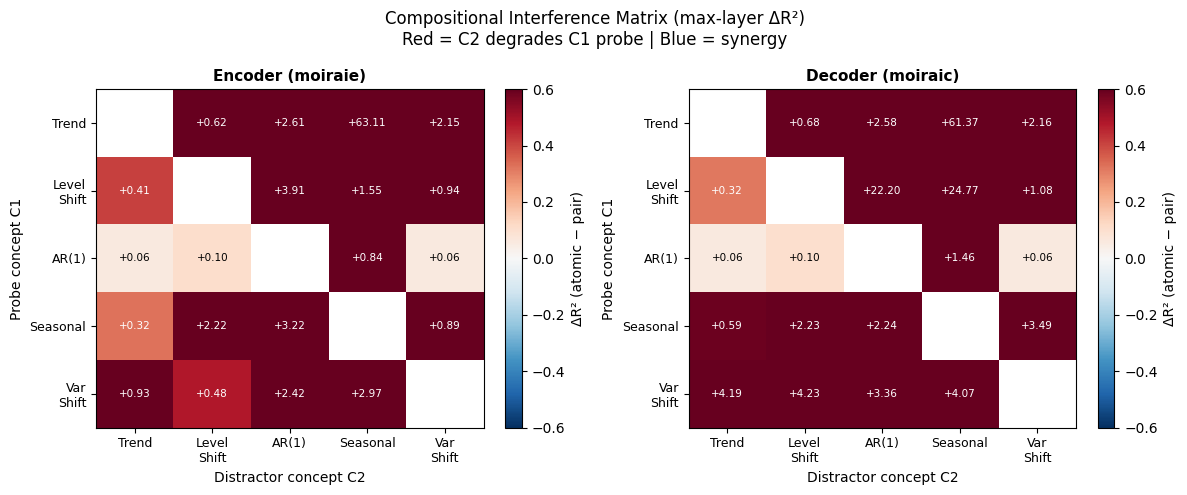

In [2]:
CONCEPTS = ["trend", "level_shift", "ar1", "seasonal", "var_shift"]
CONCEPT_LABELS = {"trend": "Trend", "level_shift": "Level\nShift",
                  "ar1": "AR(1)", "seasonal": "Seasonal", "var_shift": "Var\nShift"}

def build_interference_matrix(model_data, pooling="mean_ctx"):
    """5x5 matrix: row=C1, col=C2. Value = max-layer delta (or nan if missing)."""
    pd = model_data[pooling]
    mat = np.full((5, 5), np.nan)
    for i, c1 in enumerate(CONCEPTS):
        for j, c2 in enumerate(CONCEPTS):
            if i == j:
                continue
            key = f"{c1}\u2192{c2}"
            if key not in pd:
                continue
            deltas = [v["delta"] for v in pd[key].values() if v["delta"] is not None]
            if deltas:
                mat[i, j] = max(deltas)  # worst-case layer delta
    return mat

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
clim = 0.6
cmap = plt.cm.RdBu_r

for ax, m in zip(axes, MODELS):
    mat = build_interference_matrix(data[m])
    labels = [CONCEPT_LABELS[c] for c in CONCEPTS]
    im = ax.imshow(mat, cmap=cmap, vmin=-clim, vmax=clim, aspect="auto")
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Distractor concept C2", fontsize=10)
    ax.set_ylabel("Probe concept C1", fontsize=10)
    ax.set_title(MODEL_LABELS[m], fontsize=11, fontweight="bold")
    # annotate cells
    for i in range(5):
        for j in range(5):
            if i == j or np.isnan(mat[i, j]):
                continue
            ax.text(j, i, f"{mat[i,j]:+.2f}", ha="center", va="center",
                    fontsize=7.5, color="white" if abs(mat[i,j]) > 0.3 else "black")
    plt.colorbar(im, ax=ax, label="ΔR² (atomic − pair)", fraction=0.046)

fig.suptitle("Compositional Interference Matrix (max-layer ΔR²)\n"
             "Red = C2 degrades C1 probe | Blue = synergy", fontsize=12)
plt.tight_layout()
plt.savefig("figures/pr9_interference_heatmap.pdf", bbox_inches="tight")
plt.show()

## 2. Layer-wise curves: atomic vs pair R² for each C1

For each concept C1, plot the per-layer atomic score (dashed) and all pair scores (solid),
showing how the probe degrades across layers when a second concept is present.

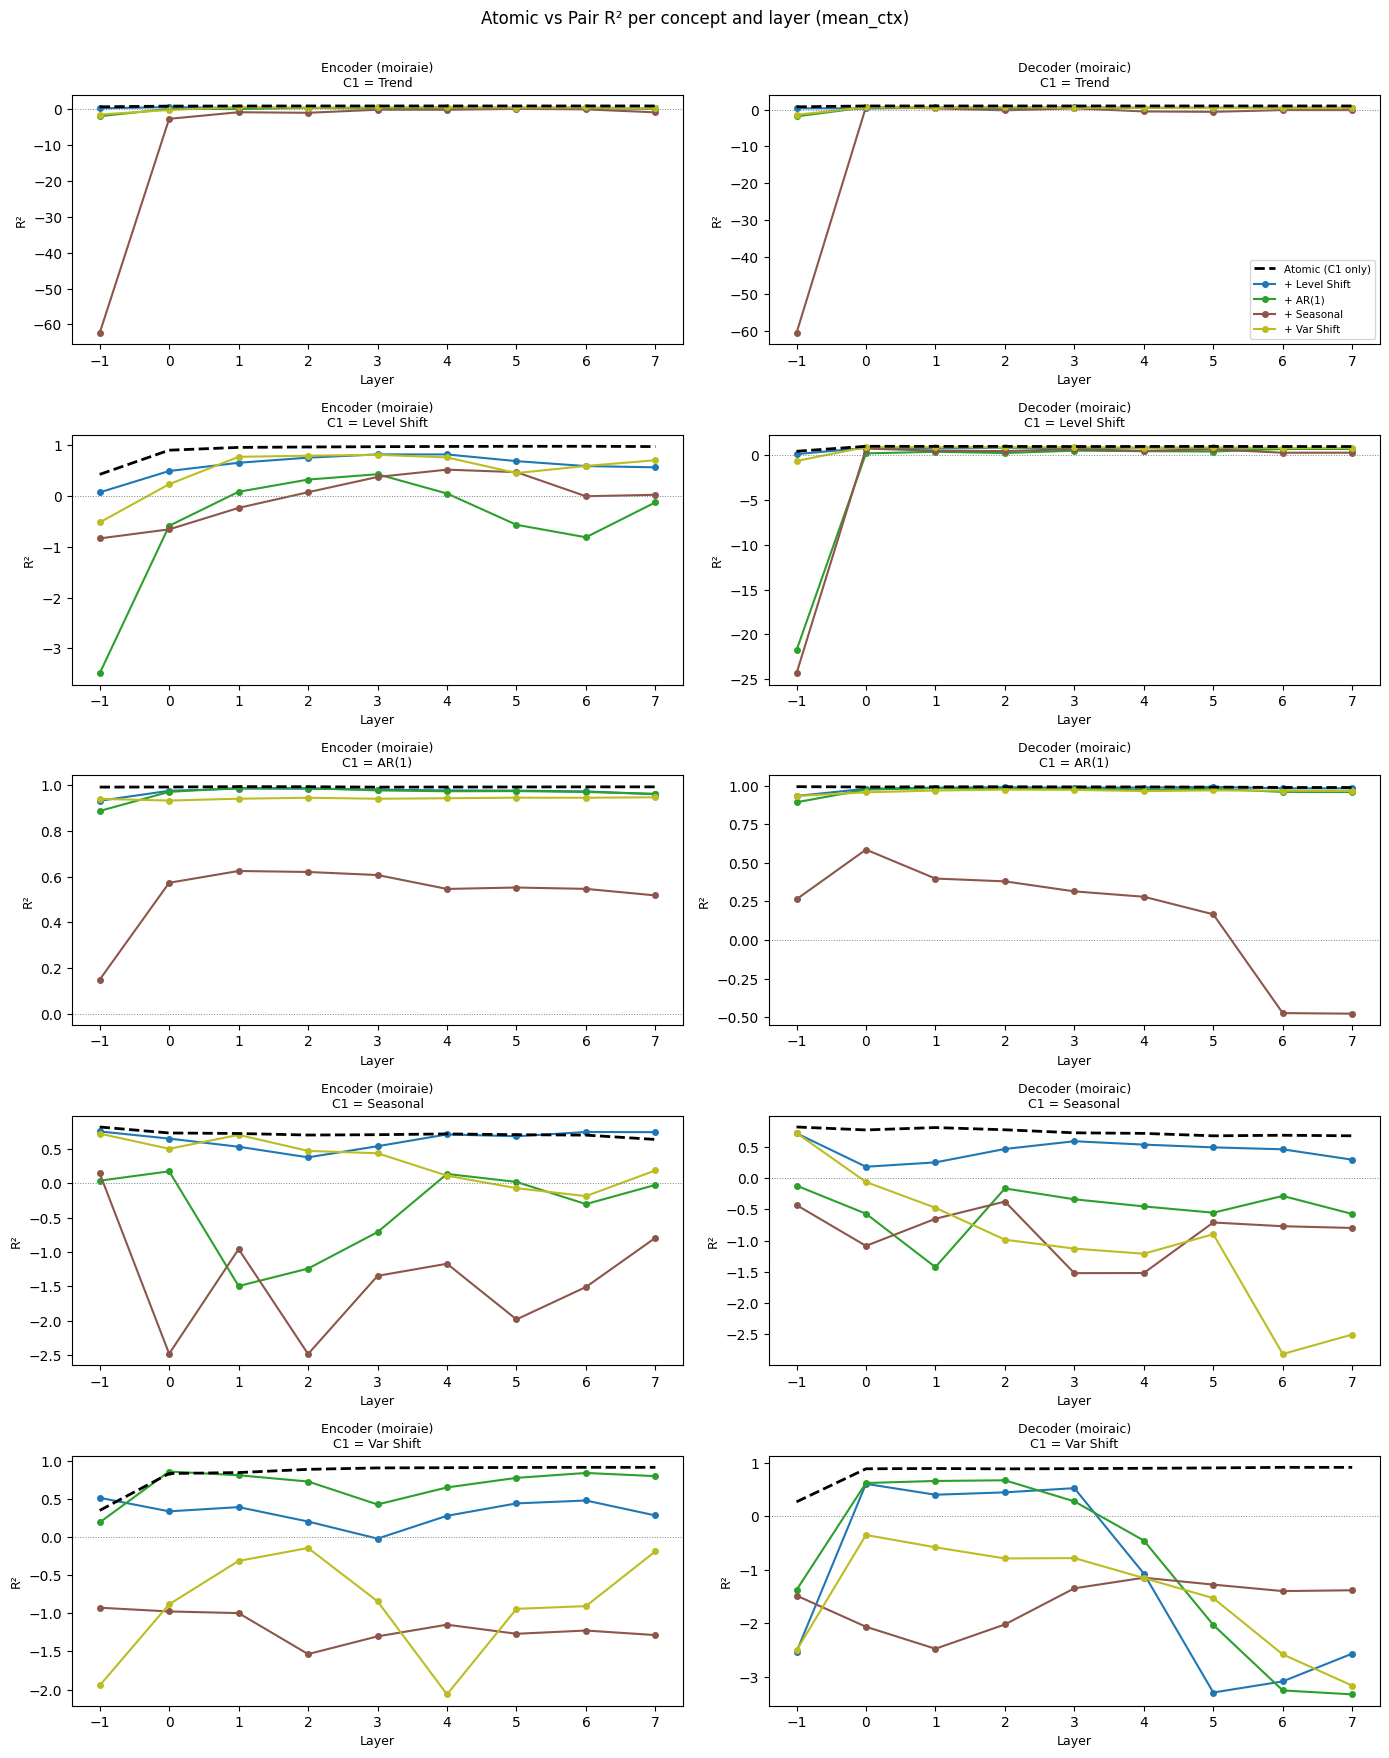

In [3]:
POOLING = "mean_ctx"
PAIR_COLORS = plt.cm.tab10(np.linspace(0, 0.8, 4))

fig, axes = plt.subplots(len(CONCEPTS), 2, figsize=(14, 3.5 * len(CONCEPTS)), sharey=False)

for row, c1 in enumerate(CONCEPTS):
    for col, m in enumerate(MODELS):
        ax = axes[row, col]
        pd = data[m][POOLING]
        others = [c for c in CONCEPTS if c != c1]

        # Atomic line (same for all C2 — probe trained on same atomic_tr)
        key0 = f"{c1}\u2192{others[0]}"
        if key0 in pd:
            atomic_scores = [pd[key0][str(l)]["atomic"] for l in LAYERS]
            ax.plot(LAYERS, atomic_scores, "k--", lw=2, label="Atomic (C1 only)", zorder=5)

        # Pair lines
        for ci, c2 in enumerate(others):
            key = f"{c1}\u2192{c2}"
            if key not in pd:
                continue
            pair_scores = [pd[key][str(l)]["pair"] for l in LAYERS]
            valid = [(l, s) for l, s in zip(LAYERS, pair_scores) if s is not None]
            if valid:
                ls_, ss_ = zip(*valid)
                ax.plot(ls_, ss_, color=PAIR_COLORS[ci], lw=1.5,
                        marker="o", markersize=4,
                        label=f"+ {CONCEPT_LABELS[c2].replace(chr(10), ' ')}")

        ax.axhline(0, color="gray", lw=0.7, ls=":")
        ax.set_xticks(LAYERS)
        ax.set_xlabel("Layer", fontsize=9)
        ax.set_ylabel("R²", fontsize=9)
        title = f"{MODEL_LABELS[m]}\nC1 = {CONCEPT_LABELS[c1].replace(chr(10),' ')}"
        ax.set_title(title, fontsize=9)
        if row == 0 and col == 1:
            ax.legend(fontsize=7.5, loc="lower right")

fig.suptitle(f"Atomic vs Pair R² per concept and layer ({POOLING})", fontsize=12, y=1.002)
plt.tight_layout()
plt.savefig("figures/pr9_layer_curves.pdf", bbox_inches="tight")
plt.show()

## 3. Mean ΔR² per concept across all distractors (bar chart)

For each C1, average the best-layer ΔR² over all 4 C2 distractors.
Positive = on average, co-presence of any other concept hurts C1's readout.

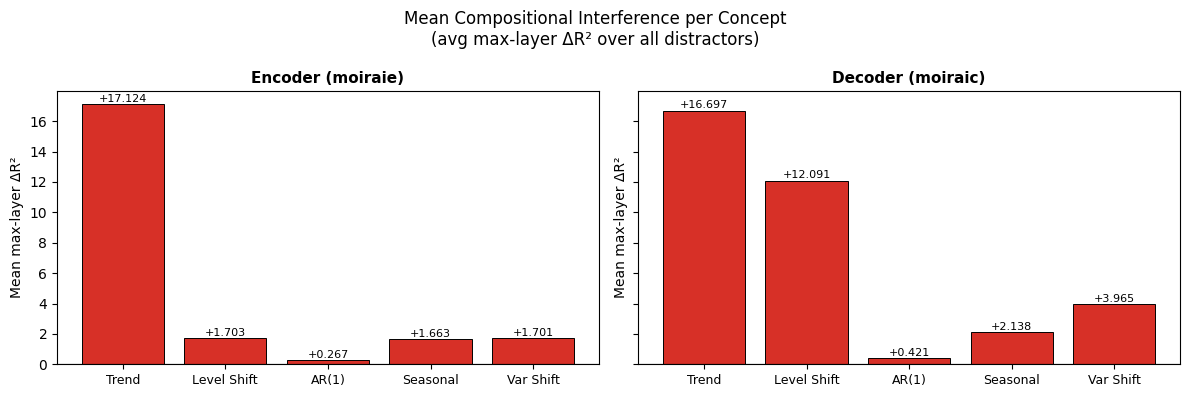

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, m in zip(axes, MODELS):
    pd = data[m][POOLING]
    mean_deltas = []
    for c1 in CONCEPTS:
        deltas = []
        for c2 in CONCEPTS:
            if c2 == c1:
                continue
            key = f"{c1}\u2192{c2}"
            if key not in pd:
                continue
            ds = [v["delta"] for v in pd[key].values() if v["delta"] is not None]
            if ds:
                deltas.append(max(ds))
        mean_deltas.append(np.mean(deltas) if deltas else np.nan)

    colors = ["#d73027" if d > 0 else "#4575b4" for d in mean_deltas]
    bars = ax.bar(range(5), mean_deltas, color=colors, edgecolor="black", linewidth=0.7)
    ax.set_xticks(range(5))
    ax.set_xticklabels([CONCEPT_LABELS[c].replace("\n", " ") for c in CONCEPTS], fontsize=9)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("Mean max-layer ΔR²", fontsize=10)
    ax.set_title(MODEL_LABELS[m], fontsize=11, fontweight="bold")

    for bar, d in zip(bars, mean_deltas):
        if not np.isnan(d):
            ax.text(bar.get_x() + bar.get_width() / 2, d + 0.01 * np.sign(d),
                    f"{d:+.3f}", ha="center", va="bottom" if d >= 0 else "top", fontsize=8)

fig.suptitle("Mean Compositional Interference per Concept\n"
             "(avg max-layer ΔR² over all distractors)", fontsize=12)
plt.tight_layout()
plt.savefig("figures/pr9_mean_interference.pdf", bbox_inches="tight")
plt.show()

## 4. Encoder vs Decoder: ΔR² comparison per pair

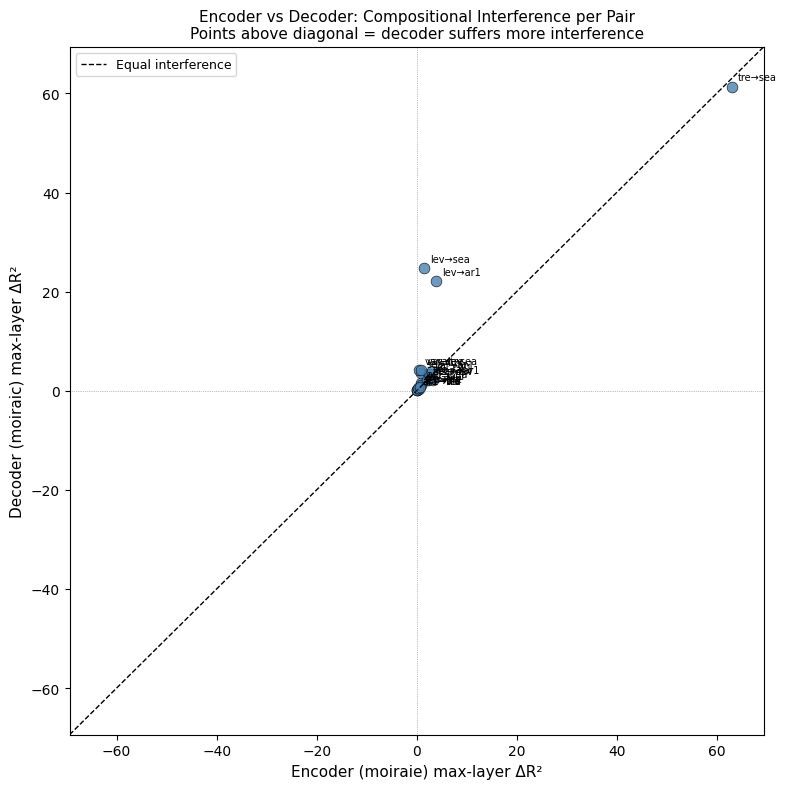

Encoder mean ΔR²: 4.4916
Decoder mean ΔR²: 7.0624
Encoder > Decoder in 5/20 pairs


In [5]:
fig, ax = plt.subplots(figsize=(8, 8))

e_deltas, c_deltas, labels_xy = [], [], []
for key in PAIR_KEYS:
    for m, lst in [("moiraie", e_deltas), ("moiraic", c_deltas)]:
        ds = [v["delta"] for v in data[m][POOLING][key].values() if v["delta"] is not None]
        lst.append(max(ds) if ds else np.nan)
    labels_xy.append(key.replace("\u2192", "→"))

e_arr = np.array(e_deltas)
c_arr = np.array(c_deltas)
valid = ~(np.isnan(e_arr) | np.isnan(c_arr))

ax.scatter(e_arr[valid], c_arr[valid], s=60, alpha=0.8, color="steelblue", edgecolors="black", lw=0.5)
for x, y, lbl in zip(e_arr[valid], c_arr[valid], np.array(labels_xy)[valid]):
    c1, c2 = lbl.split("→")
    short = f"{c1[:3]}→{c2[:3]}"
    ax.annotate(short, (x, y), fontsize=7, ha="left", va="bottom",
                xytext=(4, 3), textcoords="offset points")

lim = max(np.nanmax(np.abs(e_arr)), np.nanmax(np.abs(c_arr))) * 1.1
ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, label="Equal interference")
ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.axvline(0, color="gray", lw=0.5, ls=":")
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel("Encoder (moiraie) max-layer ΔR²", fontsize=11)
ax.set_ylabel("Decoder (moiraic) max-layer ΔR²", fontsize=11)
ax.set_title("Encoder vs Decoder: Compositional Interference per Pair\n"
             "Points above diagonal = decoder suffers more interference", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figures/pr9_encoder_vs_decoder.pdf", bbox_inches="tight")
plt.show()

print(f"Encoder mean ΔR²: {np.nanmean(e_arr):.4f}")
print(f"Decoder mean ΔR²: {np.nanmean(c_arr):.4f}")
print(f"Encoder > Decoder in {(e_arr[valid] > c_arr[valid]).sum()}/{valid.sum()} pairs")

## 5. Summary table

In [6]:
rows = []
for key in PAIR_KEYS:
    c1, c2 = key.split("\u2192")
    row = {"C1": c1, "C2": c2}
    for m in MODELS:
        pd_ = data[m][POOLING][key]
        # best atomic R² across layers
        best_atomic = max(v["atomic"] for v in pd_.values())
        # best-layer delta (could be negative)
        deltas = [v["delta"] for v in pd_.values() if v["delta"] is not None]
        best_delta = max(deltas) if deltas else float("nan")
        row[f"{m}_atomic"] = round(best_atomic, 4)
        row[f"{m}_delta"] = round(best_delta, 4) if not np.isnan(best_delta) else None
    rows.append(row)

# Print table
header = f"{'C1→C2':<30} {'ie_atomic':>10} {'ie_delta':>10} {'ic_atomic':>10} {'ic_delta':>10}"
print(header)
print("-" * len(header))
for r in rows:
    key = f"{r['C1']}→{r['C2']}"
    ie_d = f"{r['moiraie_delta']:+.4f}" if r["moiraie_delta"] is not None else "  skip"
    ic_d = f"{r['moiraic_delta']:+.4f}" if r["moiraic_delta"] is not None else "  skip"
    print(f"{key:<30} {r['moiraie_atomic']:>10.4f} {ie_d:>10} {r['moiraic_atomic']:>10.4f} {ic_d:>10}")

C1→C2                           ie_atomic   ie_delta  ic_atomic   ic_delta
--------------------------------------------------------------------------
ar1→level_shift                    0.9946    +0.1047     0.9927    +0.1010
ar1→seasonal                       0.9946    +0.8436     0.9927    +1.4632
ar1→trend                          0.9946    +0.0600     0.9927    +0.0606
ar1→var_shift                      0.9946    +0.0593     0.9927    +0.0604
level_shift→ar1                    0.9700    +3.9064     0.9741   +22.1977
level_shift→seasonal               0.9700    +1.5545     0.9741   +24.7698
level_shift→trend                  0.9700    +0.4091     0.9741    +0.3162
level_shift→var_shift              0.9700    +0.9428     0.9741    +1.0815
seasonal→ar1                       0.8207    +3.2162     0.8136    +2.2409
seasonal→level_shift               0.8207    +2.2223     0.8136    +2.2290
seasonal→trend                     0.8207    +0.3248     0.8136    +0.5876
seasonal→var_shift       